# Reciprocal OLS asymmetry and SVD-normalized maps

This notebook constructs matched Gaussian observations with rows as samples:

$$X\in\mathbb{R}^{n\times 2},\qquad Y=[XA^\top+sE\;|\;E_{\mathrm{extra}}]\in\mathbb{R}^{n\times 4},$$

where $X\sim\mathcal N(0,I_2)$, $AA^\top=\Sigma_{Y,\mathrm{signal}}$, $E\sim\mathcal N(0,\Sigma_E)$ is independent of $X$, $s$ is the noise scale, and $E_{\mathrm{extra}}\sim\mathcal N(0,I_2)$ is independent of all other variables. The configuration directly exposes $\Sigma_{Y,\mathrm{signal}}$, $\Sigma_E$, and $s$. For isotropic noise, set $\Sigma_E=\sigma_E^2 I_2$. The theoretical covariance of the first two dimensions is

$$\operatorname{Cov}(Y_{1:2})=\Sigma_{Y,\mathrm{signal}}+s^2\Sigma_E,$$

while $\operatorname{Cov}(Y_{3:4})=I_2$.

All regressions are ordinary least squares fitted and evaluated on the complete dataset, as requested (no cross-validation). Both the per-output and uniformly averaged reciprocal $R^2$ values are reported.

## Matrix convention for removing $\Sigma$

The project regression wrapper stores coefficients as an output-by-input matrix $B$, so predictions for row-wise samples are $X B^\top+b$. If

$$B=U\Sigma V^\top,$$

then removing the singular values gives $\widetilde B=UV^\top$. The corresponding row-wise transform requested in the prompt is therefore

$$\widetilde W=\widetilde B^\top=VU^\top.$$

This convention gives $\widetilde W_{X\to Y}\in\mathbb{R}^{2\times4}$ and $\widetilde W_{Y\to X}\in\mathbb{R}^{4\times2}$, so $\widetilde X=X\widetilde W_{X\to Y}$ and $\widetilde Y=Y\widetilde W_{Y\to X}$ are well-defined.

In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

# Locate config.yaml whether Jupyter starts in the repository root or scripts folder.
cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in [cwd, *cwd.parents] if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml from the current directory.")
# end if PROJECT_ROOT is None

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    project_config = yaml.safe_load(f)
paths = project_config[ENV]["paths"]
sys.path.append(paths["useful_stuff_path"])

from useful_stuff.general_utils.regression import linear_encoding

plt.rcParams.update(
    {"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False}
)

In [11]:
@dataclass
class Cfg:
    n: int = 2_000
    seed: int = 20260805
    # Covariance of the noiseless anisotropic component X @ A.T.
    y_covariance: tuple = ((1.0, 0), (0, 1.0))
    # Covariance of E before multiplying it by noise_scale.
    noise_covariance: tuple = ((2, 0), (0, 0.001))
    noise_scale: float = 10
    scatter_size: float = 10.0
    scatter_alpha: float = 0.45
# EOC


cfg = Cfg()
cfg

Cfg(n=2000, seed=20260805, y_covariance=((1.0, 0), (0, 1.0)), noise_covariance=((2, 0), (0, 0.001)), noise_scale=10, scatter_size=10.0, scatter_alpha=0.45)

In [12]:
"""
covariance_square_root
Validate a symmetric positive-definite 2D covariance and return its
symmetric matrix square root.

INPUT:
    - covariance: array-like -> requested 2D covariance matrix
    - name: str -> parameter name used in validation errors

OUTPUT:
    - covariance_sqrt: np.ndarray -> shape (2, 2), whose square is covariance
"""
def covariance_square_root(covariance, name):
    covariance = np.asarray(covariance, dtype=float)
    if covariance.shape != (2, 2):
        raise ValueError(f"{name} must have shape (2, 2).")
    # end if covariance.shape != (2, 2)
    if not np.allclose(covariance, covariance.T, atol=1e-12):
        raise ValueError(f"{name} must be symmetric.")
    # end if covariance is not symmetric

    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    if np.any(eigenvalues <= 0):
        raise ValueError(f"{name} must be positive definite.")
    # end if covariance is not positive definite
    return eigenvectors @ np.diag(np.sqrt(eigenvalues)) @ eigenvectors.T
# EOF


"""
generate_matched_gaussians
Generate X, construct Y's noisy transformed first block, and append two
independent standard-Gaussian dimensions.

INPUT:
    - cfg: Cfg -> simulation parameters

OUTPUT:
    - X: np.ndarray -> standard Gaussian observations, shape (n, 2)
    - Y: np.ndarray -> noisy transformed block plus extra noise, shape (n, 4)
    - Y_signal: np.ndarray -> noiseless anisotropic component X @ A.T
    - Y_noise: np.ndarray -> scaled noise added to Y
    - Y_extra: np.ndarray -> appended N(0, I_2) dimensions
    - y_transform: np.ndarray -> A, shape (2, 2)
    - noise_transform: np.ndarray -> square root of noise covariance
"""
def generate_matched_gaussians(cfg):
    if cfg.n <= 4:
        raise ValueError("n must exceed the four dimensions of Y.")
    # end if cfg.n <= 4
    if cfg.noise_scale < 0:
        raise ValueError("noise_scale must be non-negative.")
    # end if cfg.noise_scale < 0

    rng = np.random.default_rng(cfg.seed)
    X = rng.multivariate_normal(np.zeros(2), np.eye(2), size=cfg.n)

    # A is the symmetric square root, so Cov(X @ A.T) = A @ A.T = y_covariance.
    y_transform = covariance_square_root(cfg.y_covariance, "y_covariance")
    Y_signal = X @ y_transform.T

    # Draw E with the configured base covariance, then apply its separate scale.
    noise_transform = covariance_square_root(
        cfg.noise_covariance, "noise_covariance"
    )
    standard_noise = rng.multivariate_normal(np.zeros(2), np.eye(2), size=cfg.n)
    Y_noise = cfg.noise_scale * (standard_noise @ noise_transform.T)
    Y_noisy_signal = Y_signal + Y_noise

    # Append two independent dimensions with identity covariance.
    Y_extra = rng.multivariate_normal(np.zeros(2), np.eye(2), size=cfg.n)
    Y = np.concatenate([Y_noisy_signal, Y_extra], axis=1)
    return X, Y, Y_signal, Y_noise, Y_extra, y_transform, noise_transform
# EOF


"""
fit_reciprocal_ols
Fit and evaluate full-data OLS in both directions using the project wrapper.

INPUT:
    - source: np.ndarray -> first representation with samples in rows
    - target: np.ndarray -> matched second representation with samples in rows

OUTPUT:
    - result: dict -> fitted encoders, predictions, and per-output R² arrays
"""
def fit_reciprocal_ols(source, target):
    if source.ndim != 2 or target.ndim != 2:
        raise ValueError("source and target must both be two-dimensional.")
    # end if source.ndim != 2 or target.ndim != 2
    if source.shape[0] != target.shape[0]:
        raise ValueError("source and target must contain matched observations.")
    # end if source.shape[0] != target.shape[0]

    source_to_target = linear_encoding(
        regression_type="lr", cv_type="same", score_type="r2", shuffle=False
    )
    target_to_source = linear_encoding(
        regression_type="lr", cv_type="same", score_type="r2", shuffle=False
    )

    # transpose=False keeps the notebook convention (samples, features).
    source_to_target.fit(source, target, transpose=False)
    target_to_source.fit(target, source, transpose=False)
    target_hat = source_to_target.predict(
        source, transpose=False, transpose_output=False
    )
    source_hat = target_to_source.predict(
        target, transpose=False, transpose_output=False
    )

    # Report raw R² for every target coordinate rather than hiding asymmetry in one scalar.
    r2_source_to_target = source_to_target.score(
        source,
        target,
        y_hat=target_hat,
        transpose=False,
        transpose_prediction=False,
    )
    r2_target_to_source = target_to_source.score(
        target,
        source,
        y_hat=source_hat,
        transpose=False,
        transpose_prediction=False,
    )
    return {
        "source_to_target": source_to_target,
        "target_to_source": target_to_source,
        "target_hat": target_hat,
        "source_hat": source_hat,
        "r2_source_to_target": r2_source_to_target,
        "r2_target_to_source": r2_target_to_source,
    }
# EOF


"""
remove_singular_values
Convert a fitted output-by-input coefficient matrix into the row-wise
partial-isometry V U.T obtained after discarding its singular values.

INPUT:
    - encoding: linear_encoding -> fitted project regression wrapper

OUTPUT:
    - row_transform: np.ndarray -> input-by-output transform V U.T
    - singular_values: np.ndarray -> removed singular values
"""
def remove_singular_values(encoding):
    coefficient = np.asarray(encoding.get_weights(), dtype=float)
    U, singular_values, Vt = np.linalg.svd(coefficient, full_matrices=False)

    # coefficient = U Sigma V.T, hence the row map is (U V.T).T = V U.T.
    row_transform = Vt.T @ U.T
    return row_transform, singular_values
# EOF


"""
r2_summary
Create a tidy table with reciprocal per-output and mean R² values.

INPUT:
    - result: dict -> output of fit_reciprocal_ols
    - source_name: str -> displayed source name
    - target_name: str -> displayed target name

OUTPUT:
    - summary: pd.DataFrame -> one row for each regression direction
"""
def r2_summary(result, source_name, target_name):
    rows = []
    for direction, scores in (
        (f"{source_name} -> {target_name}", result["r2_source_to_target"]),
        (f"{target_name} -> {source_name}", result["r2_target_to_source"]),
    ):
        rows.append(
            {
                "direction": direction,
                "R2 per output": np.round(scores, 6).tolist(),
                "mean R2": float(np.mean(scores)),
            }
        )
    # end for direction, scores
    return pd.DataFrame(rows)
# EOF

## 1. Generate and visualize the matched distributions

In [13]:
X, Y, Y_signal, Y_noise, Y_extra, y_transform, noise_transform = (
    generate_matched_gaussians(cfg)
)

print(f"X shape: {X.shape}; Y shape: {Y.shape}")
theoretical_Y_covariance = (
    np.asarray(cfg.y_covariance)
    + cfg.noise_scale**2 * np.asarray(cfg.noise_covariance)
)
print("Anisotropic transform A:\n", np.round(y_transform, 4))
print("Configured covariance of noiseless A X:\n", np.asarray(cfg.y_covariance))
print("Configured base noise covariance:\n", np.asarray(cfg.noise_covariance))
print(f"Noise scale: {cfg.noise_scale:.4f}")
print("Theoretical covariance of Y[:, :2]:\n", np.round(theoretical_Y_covariance, 3))
print("Empirical covariance of X:\n", np.round(np.cov(X, rowvar=False), 3))
print("Empirical covariance of noiseless A X:\n", np.round(np.cov(Y_signal, rowvar=False), 3))
print("Empirical covariance of scaled noise:\n", np.round(np.cov(Y_noise, rowvar=False), 3))
print("Empirical covariance of Y[:, :2]:\n", np.round(np.cov(Y[:, :2], rowvar=False), 3))
print("Empirical covariance of appended Y[:, 2:]:\n", np.round(np.cov(Y_extra, rowvar=False), 3))

# Assertions make the matched signal-plus-noise construction explicit.
np.testing.assert_allclose(Y_signal, X @ y_transform.T)
np.testing.assert_allclose(Y[:, :2], Y_signal + Y_noise)
np.testing.assert_allclose(Y[:, 2:], Y_extra)
np.testing.assert_allclose(y_transform @ y_transform.T, cfg.y_covariance)
np.testing.assert_allclose(
    noise_transform @ noise_transform.T, cfg.noise_covariance
)
assert X.shape == (cfg.n, 2)
assert Y.shape == (cfg.n, 4)

X shape: (2000, 2); Y shape: (2000, 4)
Anisotropic transform A:
 [[1. 0.]
 [0. 1.]]
Configured covariance of noiseless A X:
 [[1. 0.]
 [0. 1.]]
Configured base noise covariance:
 [[2.e+00 0.e+00]
 [0.e+00 1.e-03]]
Noise scale: 10.0000
Theoretical covariance of Y[:, :2]:
 [[201.    0. ]
 [  0.    1.1]]
Empirical covariance of X:
 [[ 1.025 -0.018]
 [-0.018  0.953]]
Empirical covariance of noiseless A X:
 [[ 1.025 -0.018]
 [-0.018  0.953]]
Empirical covariance of scaled noise:
 [[2.03723e+02 3.20000e-02]
 [3.20000e-02 1.01000e-01]]
Empirical covariance of Y[:, :2]:
 [[204.314   0.25 ]
 [  0.25    1.039]]
Empirical covariance of appended Y[:, 2:]:
 [[ 0.949 -0.002]
 [-0.002  0.958]]


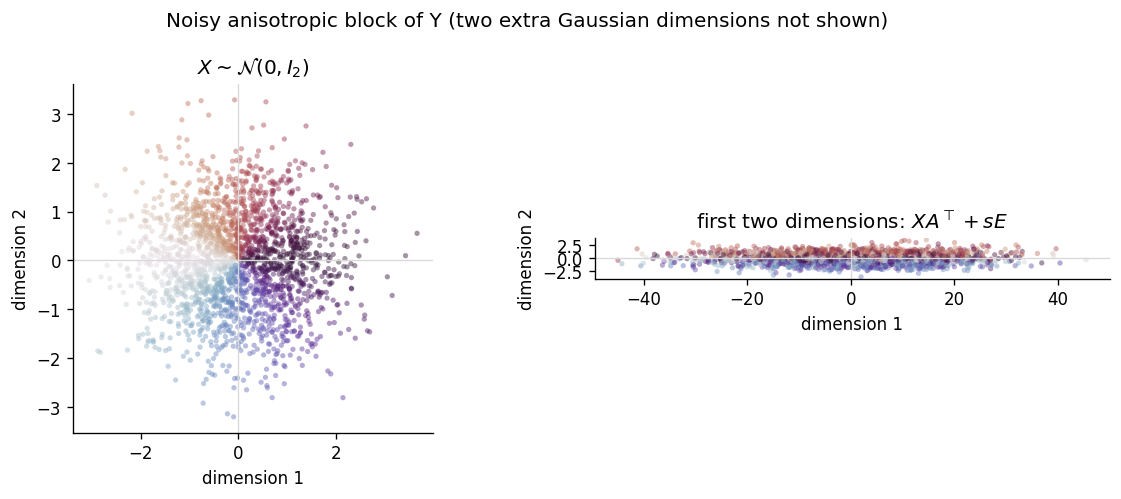

In [14]:
# Use the same color for matched observations so the transformation and noise are visible.
point_color = np.arctan2(X[:, 1], X[:, 0])
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, data, title in (
    (axes[0], X, r"$X \sim \mathcal{N}(0, I_2)$"),
    (axes[1], Y[:, :2], r"first two dimensions: $XA^\top+sE$"),
):
    ax.scatter(
        data[:, 0],
        data[:, 1],
        c=point_color,
        cmap="twilight",
        s=cfg.scatter_size,
        alpha=cfg.scatter_alpha,
        edgecolors="none",
    )
    ax.axhline(0, color="0.85", linewidth=0.8)
    ax.axvline(0, color="0.85", linewidth=0.8)
    ax.set(title=title, xlabel="dimension 1", ylabel="dimension 2")
    ax.set_aspect("equal", adjustable="box")
# end for ax, data, title
fig.suptitle("Noisy anisotropic block of Y (two extra Gaussian dimensions not shown)")
fig.tight_layout()
plt.show()

## 2. Reciprocal OLS on the original representations

$X\to Y$ recovers the noiseless component $XA^\top$ but cannot predict its additive noise or the two appended independent dimensions. Conversely, $Y\to X$ estimates $X$ from the noisy anisotropic block; the appended dimensions carry no population information about $X$. The reciprocal scores can therefore be strongly asymmetric.

In [15]:
original_ols = fit_reciprocal_ols(X, Y)
original_r2 = r2_summary(original_ols, "X", "Y")
display(original_r2.style.format({"mean R2": "{:.6f}"}))

original_gap = abs(
    original_r2.loc[0, "mean R2"] - original_r2.loc[1, "mean R2"]
)
print(f"Absolute reciprocal mean-R² gap: {original_gap:.6f}")

# Confirm that both scores are finite and the added noise prevents exact recovery.
assert np.isfinite(original_ols["r2_source_to_target"]).all()
assert np.isfinite(original_ols["r2_target_to_source"]).all()
# assert original_r2["mean R2"].max() < 1 - 1e-6

,direction,R2 per output,mean R2
0,X -> Y,"[0.00338, 0.903082, 0.000556, 3.5e-05]",0.226763
1,Y -> X,"[0.003853, 0.903107]",0.453480


Absolute reciprocal mean-R² gap: 0.226717


## 3. Remove the singular values and transform both representations

For each fitted coefficient matrix, the next cell retains only its two orthogonal singular-vector factors. This removes axis-specific gain while preserving the fitted subspace and orientation.

In [16]:
W_tilde_X_to_Y, singular_values_X_to_Y = remove_singular_values(
    original_ols["source_to_target"]
)
W_tilde_Y_to_X, singular_values_Y_to_X = remove_singular_values(
    original_ols["target_to_source"]
)

# Apply the rectangular row transforms exactly as specified.
X_tilde = X @ W_tilde_X_to_Y
Y_tilde = Y @ W_tilde_Y_to_X

print("removed singular values, X -> Y:", np.round(singular_values_X_to_Y, 6))
print("removed singular values, Y -> X:", np.round(singular_values_Y_to_X, 6))
print(f"W_tilde_X_to_Y: {W_tilde_X_to_Y.shape}; X_tilde: {X_tilde.shape}")
print(f"W_tilde_Y_to_X: {W_tilde_Y_to_X.shape}; Y_tilde: {Y_tilde.shape}")

# The thin polar factors are semi-orthogonal in the smaller two-dimensional space.
np.testing.assert_allclose(
    W_tilde_X_to_Y @ W_tilde_X_to_Y.T, np.eye(2), atol=1e-10
)
np.testing.assert_allclose(
    W_tilde_Y_to_X.T @ W_tilde_Y_to_X, np.eye(2), atol=1e-10
)

removed singular values, X -> Y: [1.057281 0.742688]
removed singular values, Y -> X: [0.910354 0.025195]
W_tilde_X_to_Y: (2, 4); X_tilde: (2000, 4)
W_tilde_Y_to_X: (4, 2); Y_tilde: (2000, 2)


## 4. Visualize the SVD-normalized representations

$\widetilde X$ is four-dimensional, so its first two coordinates are shown. $\widetilde Y$ is two-dimensional and is shown in full. Colors continue to identify the same matched observations.

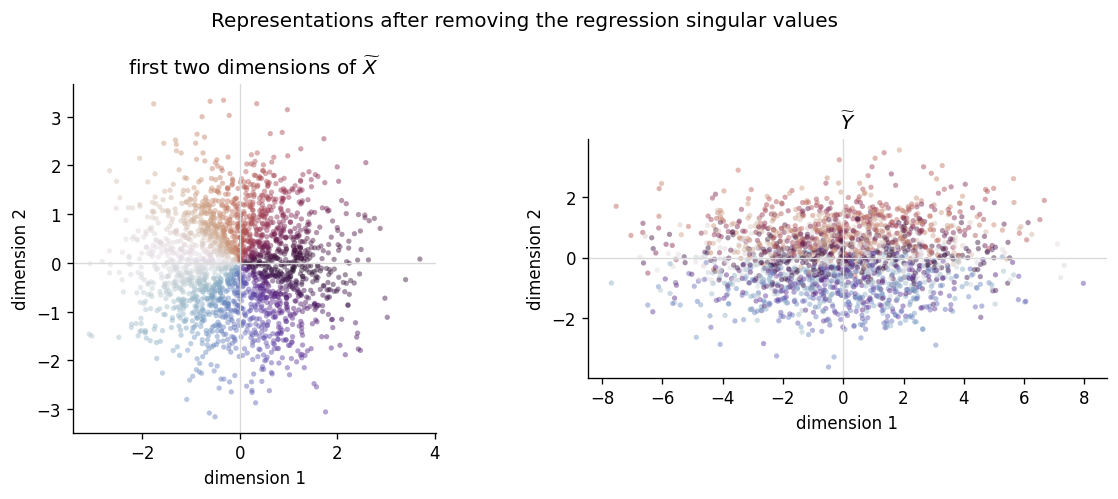

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, data, title in (
    (axes[0], X_tilde[:, :2], r"first two dimensions of $\widetilde X$"),
    (axes[1], Y_tilde, r"$\widetilde Y$"),
):
    ax.scatter(
        data[:, 0],
        data[:, 1],
        c=point_color,
        cmap="twilight",
        s=cfg.scatter_size,
        alpha=cfg.scatter_alpha,
        edgecolors="none",
    )
    ax.axhline(0, color="0.85", linewidth=0.8)
    ax.axvline(0, color="0.85", linewidth=0.8)
    ax.set(title=title, xlabel="dimension 1", ylabel="dimension 2")
    ax.set_aspect("equal", adjustable="box")
# end for ax, data, title
fig.suptitle("Representations after removing the regression singular values")
fig.tight_layout()
plt.show()

## 5. Reciprocal OLS after the SVD-normalized transforms

$\widetilde X$ has four coordinates but rank two, while $\widetilde Y$ has two coordinates. Removing $\Sigma$ eliminates regression gain but cannot remove the additive or appended noise in $Y$. The reciprocal scores below test whether this normalization removes the original asymmetry.

In [18]:
transformed_ols = fit_reciprocal_ols(X_tilde, Y_tilde)
transformed_r2 = r2_summary(
    transformed_ols, r"X_tilde", r"Y_tilde"
)
display(transformed_r2.style.format({"mean R2": "{:.12f}"}))

transformed_gap = abs(
    transformed_r2.loc[0, "mean R2"] - transformed_r2.loc[1, "mean R2"]
)
print(f"Absolute reciprocal mean-R² gap after normalization: {transformed_gap:.3e}")

# Check numerical validity without assuming that SVD normalization removes noise.
assert np.isfinite(transformed_ols["r2_source_to_target"]).all()
assert np.isfinite(transformed_ols["r2_target_to_source"]).all()


,direction,R2 per output,mean R2
0,X_tilde -> Y_tilde,"[0.003904, 0.902155]",0.453029789177
1,Y_tilde -> X_tilde,"[0.015032, 0.88582, 0.011574, 0.431044]",0.335867588947


Absolute reciprocal mean-R² gap after normalization: 1.172e-01


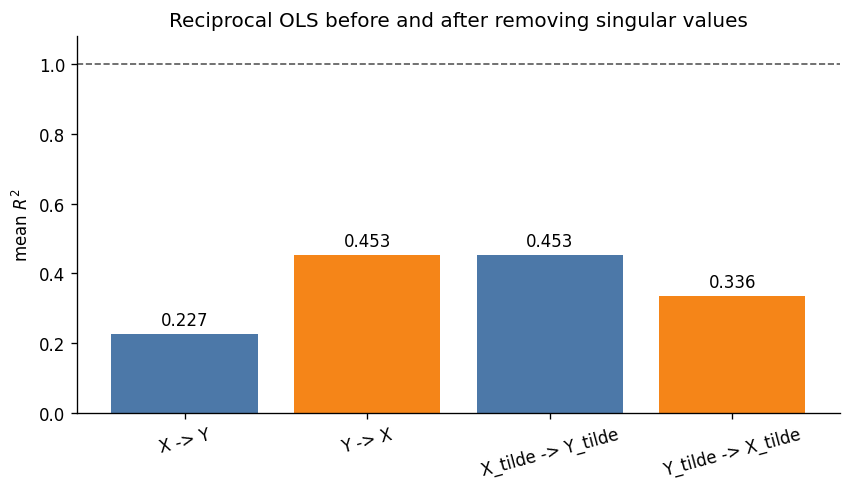

,stage,direction,mean R2
0,original,X -> Y,0.226763
1,original,Y -> X,0.453480
2,SVD-normalized,X_tilde -> Y_tilde,0.453030
3,SVD-normalized,Y_tilde -> X_tilde,0.335868


In [19]:
# Summarize how singular-value removal changes the directional mean R² values.
comparison = pd.DataFrame(
    {
        "stage": ["original", "original", "SVD-normalized", "SVD-normalized"],
        "direction": ["X -> Y", "Y -> X", "X_tilde -> Y_tilde", "Y_tilde -> X_tilde"],
        "mean R2": [
            original_r2.loc[0, "mean R2"],
            original_r2.loc[1, "mean R2"],
            transformed_r2.loc[0, "mean R2"],
            transformed_r2.loc[1, "mean R2"],
        ],
    }
)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
colors = ["#4C78A8", "#F58518", "#4C78A8", "#F58518"]
bars = ax.bar(comparison["direction"], comparison["mean R2"], color=colors)
ax.axhline(1, color="0.35", linestyle="--", linewidth=1)
ax.set(ylabel=r"mean $R^2$", ylim=(0, 1.08), title="Reciprocal OLS before and after removing singular values")
ax.tick_params(axis="x", rotation=15)
ax.bar_label(bars, fmt="%.3f", padding=3)
fig.tight_layout()
plt.show()

comparison